In [1]:
from run_inference import *

def load_models(name="best", expt_id=None, device="cpu"):
    if expt_id is None:
        expt_id = experiment_id

    if name not in ["best", "last", "latest"]:
        raise NotImplementedError("Only `best`, `last`, and `latest` models are supported")
    
    if name=="best":
        suffix = ""
    else:
        suffix = f"_{name}"
    
    print(f"Loading `{name}` model")

    model = torch.load(f"models/{expt_id}/model{suffix}.pt", map_location=device)
    scoremodel = torch.load(f"models/{expt_id}/scmodel{suffix}.pt", map_location=device)
    embed_model = torch.load(f"models/{expt_id}/embed_model{suffix}.pt", map_location=device)
    if os.path.exists(f"models/{expt_id}/preembed_model{suffix}.pt"):
        preembed_model = torch.load(f"models/{expt_id}/preembed_model{suffix}.pt", map_location=device)
    else:
        tokenize_transform = lambda x: tokenize(x, args)[0]
        preembed_model = TransformInput(tokenize_transform).to(device)
    
    if os.path.exists(f"models/{expt_id}/aggregator{suffix}.pt"):
        aggregator = torch.load(f"models/{expt_id}/aggregator{suffix}.pt", map_location=device)
    else:
        aggregator = None

    return model, scoremodel, embed_model, preembed_model, aggregator

In [7]:
args = argparse.Namespace(expt_id="A01091914", dataset="audio", device=0)

experiment_id = args.expt_id
expt_root = f"models/{experiment_id}/"
dataset = args.dataset
args.device = 1
DEVICE = f"cuda:{args.device}" if torch.cuda.is_available() and args.device != -1 else "cpu"

import pickle
with open(os.path.join(expt_root, "args.pkl"), "rb") as file:
    args = pickle.load(file)

model, scoremodel, embed_model, preembed_model, aggregator = load_models(name="best", expt_id=experiment_id, device=DEVICE)
model.eval(), scoremodel.eval(), embed_model.eval(), preembed_model.eval()
if aggregator is not None:
    aggregator.eval()

nwt, lamwt = next(scoremodel.parameters()).exp().detach().cpu()
nwt, lamwt = nwt.item(), lamwt.item()

print(f"normscore weight: {nwt:.4f}, lamscore weight: {lamwt:.4f}")

DATA_ROOT = f"final_data/{dataset}"
TEST_FILE = f"{DATA_ROOT}/dataset_test.hdf5"

image_embed_model = None
if "cifar" in dataset:
    image_embed_model_ckpt = "data/image_sequence/embedding_models/cifar_ae.pkl"
    image_embed_model = Autoencoder()
    image_embed_model.load_state_dict(torch.load(image_embed_model_ckpt))
    image_embed_model.eval()

    for param in image_embed_model.parameters():
        param.requires_grad = False

    image_embed_model = image_embed_model.to(DEVICE)
    TEST_FILE = f"{DATA_ROOT}/dataset_test_orig.hdf5"

if "lsun" in dataset:
    image_embed_model_ckpt = "data/image_sequence/embedding_models/lsun_ae.pkl"
    image_embed_model = LSUNAutoencoder()
    image_embed_model.load_state_dict(torch.load(image_embed_model_ckpt))
    image_embed_model.eval()

    for param in image_embed_model.parameters():
        param.requires_grad = False

    image_embed_model = image_embed_model.to(DEVICE)
    TEST_FILE = f"{DATA_ROOT}/dataset_test_orig.hdf5"

test_dataset = PairDatasetTest(TEST_FILE)
print(f"test subset of dataset: \"{dataset}\" loaded from {TEST_FILE}")

##### HPARAMS ######
b = args.b          # hinge margin for negative gap penalty (b-Apa)
b1 = args.b1         # hinge margin for positive gap penalty (Apa-b)
delta = args.delta     # hinge margin for contrastive loss
lr = args.lr
nepochs = args.nepochs
stagger = args.stagger
lamwt = args.lamwt    # loss coefficient for negative gap penalty
gapwt = args.gapwt       # loss coefficient for positive gap penalty
M = 6
N = 20
####################

A_mat, a_vec, Rm_mat = get_opas_constants(M, N, DEVICE)

CFG = AttributeDict({
    'tau': 1,
    'n_sink_iter': 20,
    'n_samples': 1,
})

Loading `best` model
normscore weight: 3.5466, lamscore weight: 0.3973
test subset of dataset: "audio" loaded from final_data/audio/dataset_test.hdf5


In [8]:
C = embed_full_corpus(test_dataset, embed_model, preembed_model, image_embed_model=image_embed_model, aggregator=aggregator)

In [9]:
SEED = 42069

with torch.no_grad():
    torch.manual_seed(SEED)
    loader = test_dataset.get_dataloader(batch_size=10, shuffle=True)
    q, l = next(iter(loader))

    q = q.to(next(model.parameters()).device) 
    # q is bmd, c is Nnd, l is bN
    q = q + batch_get_white_noise(q, args.SNR)     # torch.randn_like(q) * noise
    q = embed_if_image_and_normalize(q, image_embed_model)
    q = embed_model(preembed_model(q))
    q = normalize(q)
    # q is (b, m, xoutdim)
    if aggregator is None:
        qct = torch.einsum("bmd,Nnd->bNmn", q, C)
        model_inputs = stagger_and_concat(qct, num_stagger=stagger) # bNsmn  s = num_stagger+1

        lambdas = torch.stack([model(x) for x in model_inputs])
        # bNm1

        F_mat = Rm_mat.T @ (2*qct + (a_vec @ lambdas.transpose(2,3) @ A_mat).transpose(2,3))

        P = gumbel_sinkhorn(F_mat, CFG.tau, CFG.n_sink_iter, noise=False)

        RmPC = Rm_mat @ P @ C.squeeze(-1)

        lamscore = lamwt * (lambdas.transpose(2,3) @ (b-A_mat @ Rm_mat @ P @ a_vec)).squeeze()
        normscore = torch.norm(q.unsqueeze(1) - RmPC, dim=[-1,-2])

        allscores = torch.stack([lamscore, normscore], dim=2)
        netscore = 2*scoremodel(-allscores).squeeze()      # b
    else:
        q = aggregator(q)
        # q is bd, C is Nd, we want bN scores
        # b1d - 1Nd = bNd --> sum across last dim to get bN scores
        netscore = 2 * F.sigmoid(-F.relu(q.unsqueeze(1) - C.unsqueeze(0)).sum(dim=-1))    # bN

    netscores = netscore.cpu()
    true_labels = l.cpu()

    ranking = netscores.argsort(dim=1, descending=True)
    ranked_output = torch.gather(true_labels, dim=1, index=ranking)

    mRR = (1 / (ranked_output.argmax(dim=1) + 1)).mean().item()

    MAP = (torch.cumsum(ranked_output, dim=1) * ranked_output).float()
    MAP /= (torch.arange(ranked_output.shape[1]) + 1)
    MAP /= torch.sum(ranked_output, dim=1, keepdim=True)
    MAP = MAP.sum(dim=1).mean().item()

    print(f"mRR: {mRR:.4f}, mAP: {MAP:.4f}")

mRR: 1.0000, mAP: 1.0000


In [10]:
torch.manual_seed(SEED)
loader = test_dataset.get_dataloader(batch_size=10, shuffle=True)
q, l = next(iter(loader))

def get_true_mapping(idx):
    query = q[idx].cpu()
    label = l[idx].cpu()
    cpos_locs = label.nonzero().squeeze()
    corpuses = torch.from_numpy(test_dataset.c[cpos_locs])

    mapping = []
    for i in range(len(query)):
        for j in range(len(corpuses[0])):
            dist = torch.norm(query[i] - corpuses[0][j])
            if dist < 1e-8:
                mapping.append(j)
    return mapping, cpos_locs

info = [get_true_mapping(i) for i in range(len(q))]

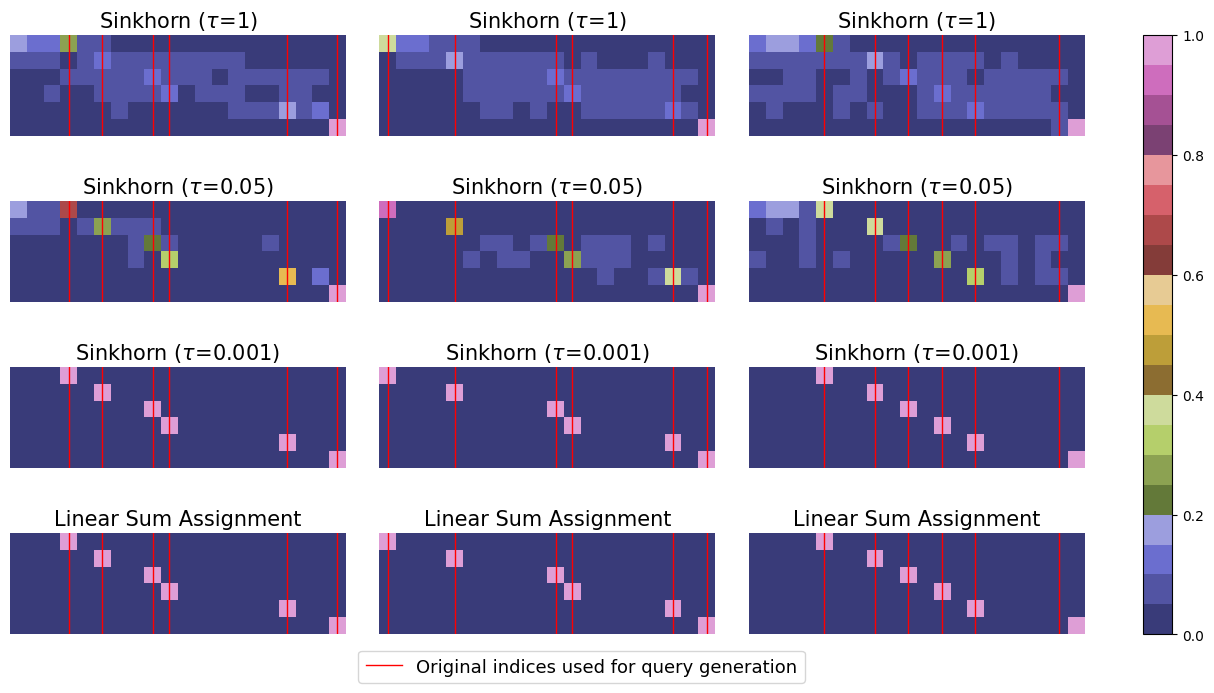

In [11]:
import matplotlib.pyplot as plt
import matplotlib as mpl

from opas.utils import gumbel_matching, gumbel_sinkhorn

axes_off = np.vectorize(lambda ax: ax.axis('off'))

plot_markersize = 10
opas_markersize = 250
opas_idmarkersize = 200
axis_fontsize = 18
title_fontsize = 15
label_fontsize = 15
cmap = "tab20b"

nsamp = 3
ridx = [0, 3, 7]
# ridx = np.random.choice(range(len(q)), nsamp, replace=False)
plot_f = False
figlen = 5 if plot_f else 4
figheight = 10 if plot_f else 8
fig, ax = plt.subplots(figlen, nsamp, figsize=(5*nsamp, figheight))
fig.subplots_adjust(hspace=0.4, wspace=0.1)
axes_off(ax)

all_perms = []
for i in range(nsamp):
    F_ = F_mat[ridx[i]][info[ridx[i]][1][0]].cpu().detach().unsqueeze(0)
    P_ = P[ridx[i]][info[ridx[i]][1][0]].cpu().detach().unsqueeze(0)
    if plot_f:
        ax[0][i].imshow(F_[0][:6], cmap=cmap)
        ax[0][i].set_title(f"Cost matrix $F$", fontsize=title_fontsize)
    for j, tau in enumerate([1, 0.05, 0.001]):
        if plot_f:
            j += 1
        P__ = gumbel_sinkhorn(P_.clone(), tau, CFG.n_sink_iter, noise=False)[0][:6]
        all_perms.append(P__)
        im = ax[j][i].imshow(P__, cmap=cmap)
        ax[j][i].set_title(fr"Sinkhorn ($\tau$={tau})", fontsize=title_fontsize)
        # plt.colorbar(im, ax=ax[j][i])
    Pm = gumbel_matching(F_, noise=False)[0][:6]
    all_perms.append(Pm)
    im = ax[-1][i].imshow(Pm, cmap=cmap)
    ax[-1][i].set_title("Linear Sum Assignment", fontsize=title_fontsize)
    # plt.colorbar(im, ax=ax[-1][i])


    for j in range(figlen):
        for loc in info[ridx[i]][0]:
            ax[j][i].axvline(loc, color='r', lw=1, label="Original indices used for query generation")
        if j == 0:
            handles, labels = ax[j][i].get_legend_handles_labels()

handles, labels = handles[:1], labels[:1]
fig.colorbar(im, ax=ax, fraction=0.0258)
legend = fig.legend(handles, labels, loc='lower center', ncol=5, fontsize=13)
coords = legend.get_window_extent().get_points()[0]
fig.legends = []
scale = fig.get_window_extent().get_points()[1]
fig.legend(handles, labels, bbox_to_anchor=(coords[0]/(scale[0]), coords[1]/(scale[1])+0.1), loc=2, ncol=5, fontsize=13)
# fig.savefig(f'plots_and_figures/inference_alignments_{plot_f}.pdf', bbox_inches='tight')
plt.show()

In [57]:
lambdas.shape

torch.Size([10, 4864, 6, 1])

In [104]:
idx = 0
print(" ".join(f"{i.item():.6f}" for i in lambdas[ridx[idx]][info[ridx[idx]][1][3]].flatten().cpu()))

0.000196 0.935534 0.996651 0.996651 0.996651 0.954409


In [131]:
2 * qct[0][info[ridx[idx]][1][0]][-1][-2]

tensor(0.1209, device='cuda:1')

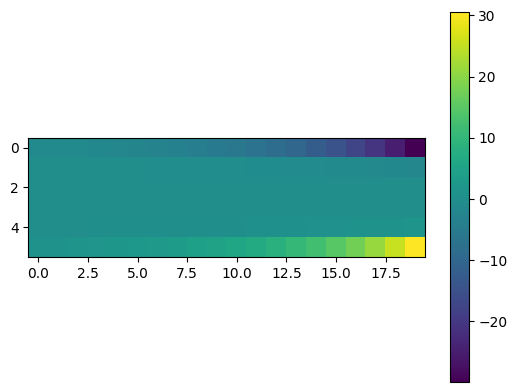

In [113]:
plt.imshow((A_mat.T @ lambdas[ridx[idx]][info[ridx[idx]][1][3]] @ a_vec.T).cpu())
plt.colorbar()

In [124]:
(A_mat.T @ lambdas[ridx[idx]][info[ridx[idx]][1][0]] @ a_vec.T).cpu()

tensor([[ -0.9339,  -1.1207,  -1.3448,  -1.6138,  -1.9366,  -2.3239,  -2.7887,
          -3.3464,  -4.0157,  -4.8188,  -5.7826,  -6.9391,  -8.3269,  -9.9923,
         -11.9908, -14.3889, -17.2667, -20.7200, -24.8640, -29.8369],
        [ -0.0627,  -0.0753,  -0.0903,  -0.1084,  -0.1301,  -0.1561,  -0.1873,
          -0.2248,  -0.2697,  -0.3237,  -0.3884,  -0.4661,  -0.5593,  -0.6712,
          -0.8054,  -0.9665,  -1.1598,  -1.3918,  -1.6701,  -2.0041],
        [  0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
           0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
           0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000],
        [  0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
           0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
           0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000],
        [  0.0445,   0.0533,   0.0640,   0.0768,   0.0922,   0.1106,   0.1328,
         

In [99]:
ridx[idx], info[ridx[idx]][1]

(0,
 tensor([1968, 1969, 1970, 1971, 1972, 1973, 1974, 1975, 1976, 1977, 1978, 1979,
         1980, 1981, 1982, 1983]))

In [40]:
from tabulate import tabulate

print(tabulate(all_perms[0][:5,:10], tablefmt="grid", floatfmt=".3f"))

+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+
| 0.058 | 0.055 | 0.056 | 0.064 | 0.051 | 0.050 | 0.049 | 0.048 | 0.048 | 0.048 |
+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+
| 0.050 | 0.051 | 0.051 | 0.049 | 0.051 | 0.055 | 0.051 | 0.051 | 0.051 | 0.050 |
+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+
| 0.049 | 0.049 | 0.050 | 0.050 | 0.050 | 0.050 | 0.050 | 0.051 | 0.054 | 0.051 |
+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+
| 0.050 | 0.050 | 0.050 | 0.049 | 0.049 | 0.050 | 0.050 | 0.051 | 0.051 | 0.056 |
+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+
| 0.049 | 0.049 | 0.049 | 0.049 | 0.049 | 0.049 | 0.050 | 0.049 | 0.049 | 0.050 |
+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+


In [47]:
import pandas as pd

pd.set_option('display.precision', 3)
pd.DataFrame(all_perms[0][:5,:10])

,0,1,2,3,4,5,6,7,8,9
0,0.058,0.055,0.056,0.064,0.051,0.050,0.049,0.048,0.048,0.048
1,0.050,0.051,0.051,0.049,0.051,0.055,0.051,0.051,0.051,0.050
2,0.049,0.049,0.050,0.050,0.050,0.050,0.050,0.051,0.054,0.051
3,0.050,0.050,0.050,0.049,0.049,0.050,0.050,0.051,0.051,0.056
4,0.049,0.049,0.049,0.049,0.049,0.049,0.050,0.049,0.049,0.050


# from local

In [246]:
config = ConfigParser()
config.read("inference.config")

args = argparse.Namespace(experiment_id="A01091914", debug=False, topk=False)

experiment_id = args.experiment_id 
if experiment_id.startswith("C"):
    image_embed_model_ckpt = "cifar_ae_final.pkl"
    image_embed_model = Autoencoder()
    image_embed_model.load_state_dict(torch.load(image_embed_model_ckpt, map_location='cpu'))
    image_embed_model.eval()

    for param in image_embed_model.parameters():
        param.requires_grad = False    

elif experiment_id.startswith("L"):
    image_embed_model_ckpt = "lsun_ae_384.pkl"
    image_embed_model = LSUNAutoencoder()
    image_embed_model.load_state_dict(torch.load(image_embed_model_ckpt, map_location='cpu'))
    image_embed_model.eval()

    for param in image_embed_model.parameters():
        param.requires_grad = False

root = f"{experiment_id}/"
DEVICE = "cpu"
DEBUG = args.debug
TOPK = args.topk

In [247]:
def load_models(root, name="best"):
    if name not in ["best", "last", "latest"]:
        raise NotImplementedError("Only `best`, `last`, and `latest` models are supported")
    
    if name=="best":
        suffix = ""
    else:
        suffix = f"_{name}"
    
    logging.info(f"Loading `{name}` model")

    model = torch.load(f"{root}/model{suffix}.pt", map_location=DEVICE)
    scoremodel = torch.load(f"{root}/scmodel{suffix}.pt", map_location=DEVICE)
    embed_model = torch.load(f"{root}/embed_model{suffix}.pt", map_location=DEVICE)
    if os.path.exists(f"{root}/preembed_model{suffix}.pt"):
        preembed_model = torch.load(f"{root}/preembed_model{suffix}.pt", map_location=DEVICE)
    else:
        tokenize_transform = lambda x: tokenize(x, args)[0]
        preembed_model = TransformInput(tokenize_transform).to(DEVICE)

    return model, scoremodel, embed_model, preembed_model

if experiment_id[0] in ["C", "L"]:
    image_embed_model = image_embed_model.to(DEVICE)
    embed_if_image_and_normalize = partial(embed_if_image_and_normalize, image_embed_model=image_embed_model)

import pickle
with open(root+"args.pkl", "rb") as f:
    args = pickle.load(f)

if args.dataset == "lsun384":
    args.dataset = "lsun"
elif args.dataset == "human":
    args.dataset = "speech"

model, scoremodel, embed_model, preembed_model = load_models(root, name="best")
model.eval(); scoremodel.eval(); embed_model.eval(); preembed_model.eval()

nwt, lamwt = next(scoremodel.parameters()).exp().detach().cpu()
nwt, lamwt = nwt.item(), lamwt.item()

In [248]:
##### PARSEQ HPARAMS ######
b = args.b          # hinge margin for negative gap penalty (b-Apa)
b1 = args.b1         # hinge margin for positive gap penalty (Apa-b)
delta = args.delta     # hinge margin for contrastive loss
lr = args.lr
nepochs = args.nepochs
stagger = args.stagger
lamwt = args.lamwt    # loss coefficient for negative gap penalty
gapwt = args.gapwt       # loss coefficient for positive gap penalty
noise = args.noise
M = 6
N = 20
####################

A_mat, a_vec, Rm_mat = get_parseq_constants(M, N, DEVICE)

CFG = AttributeDict(tau=1, n_sink_iter=20, n_samples=1)

# inference times (and hparams) for all experiments stored for comparisons
GLOBAL_TIMES = AttributeDict()

if TOPK: k = [1, 2, 3]
else: k = None

In [249]:
import torch.nn.functional as F

@torch.no_grad()
def embed_full_corpus(dataset, embed_model, preembed_model, inner_batch_size=800):
    C = torch.from_numpy(dataset.c).float()
    Cembed = []
    for batch in tqdm(range(0, len(C), inner_batch_size), disable=False, leave=False):
        c = C[batch:batch+inner_batch_size].to(next(embed_model.parameters()).device)
        c = embed_if_image_and_normalize(c)
        c = embed_model(preembed_model(c))
        c = normalize(c)
        Cembed.append(c)
    C = torch.vstack(Cembed)
    return C

@torch.no_grad()
def prepare_batch(q, embed_model, preembed_model, noise_override=False):
    q = q.to(next(embed_model.parameters()).device) 
    if not noise_override:
        q = q + batch_get_white_noise(q, args.SNR)     # torch.randn_like(q) * noise
    # q is bmd, c is Nnd, l is bN
    q = embed_if_image_and_normalize(q)
    q = embed_model(preembed_model(q))
    q = normalize(q)
    return q


num_runs = 1 
test_dataset = DatasetTensors(args.dataset)

# tracemalloc.start()
ts = []
for _ in tqdm(range(num_runs), desc="Corpus Embedding"):
    start = time()
    C = embed_full_corpus(test_dataset, embed_model, preembed_model, inner_batch_size=100)
    stop = time()
    ts.append(stop-start)

mu, sig = get_mean_std(ts)
GLOBAL_TIMES.corpus_embedding = get_time_entry(ts, num_runs)
logging.info(f"Corpus embedding cost for {len(test_dataset.c)} corpus items (one-time cost): {mu:.4f}±{sig:.4f} s (averaged over {num_runs} runs)")

## PARSEQ GPU

logging.info("\n\nRunning PARSEQ (GPU)")

# tracemalloc.start()
model, scoremodel, embed_model, preembed_model = model.to(DEVICE), scoremodel.to(DEVICE), embed_model.to(DEVICE), preembed_model.to(DEVICE)
A_mat, a_vec, Rm_mat = get_parseq_constants(M, N, DEVICE)


num_c = len(C)
num_q = 10 # int(config['parseq_gpu']['num_q'])
num_runs = 1 # int(config['parseq_gpu']['num_runs'])
n_inner = 1

# torch.manual_seed(69420)
torch.manual_seed(6969)
q, l = test_dataset.q[:num_q], test_dataset.l[:num_q]

Corpus Embedding: 100%|██████████| 1/1 [01:47<00:00, 107.71s/it]


In [261]:
@torch.no_grad()
def get_batch_scores(q, l, C, model, scoremodel, embed_model, preembed_model, stagger=2, noise_override=False):
    """
    q: (b, m, d)
    l: (b, num_corpuses)
    C: (num_corpuses, n, d)

    Returns-
    netscore: (b, num_corpuses)
    l       : (b, num_corpuses)
    """
    q = prepare_batch(q, embed_model, preembed_model, noise_override=noise_override)

    qct = torch.einsum("bmd,Nnd->bNmn", q, C)
    model_inputs = stagger_and_concat(qct, num_stagger=stagger) # bNsmn  s = num_stagger+1

    lambdas = torch.stack([model(x) for x in model_inputs])
    # bNm1

    F_mat = Rm_mat.T @ (2*qct + (a_vec @ lambdas.transpose(2,3) @ A_mat).transpose(2,3))

    P = gumbel_sinkhorn(F_mat, CFG.tau, CFG.n_sink_iter, noise=False)
    # P = torch.stack([gumbel_matching(F_mat[i], noise=False) for i in range(F_mat.shape[0])])

    RmPC = Rm_mat @ P @ C.squeeze(-1)

    lamscore = lamwt * (lambdas.transpose(2,3) @ F.relu(b-A_mat @ Rm_mat @ P @ a_vec)).squeeze()
    normscore = torch.norm(q.unsqueeze(1) - RmPC, dim=[-1,-2])

    # print(lambdas[0][440:460].squeeze().T, lamscore[0][440:460], normscore[0][440:460])

    allscores = torch.stack([lamscore, normscore], dim=2)
    netscore = 2*scoremodel(-allscores).squeeze()      # b

    return netscore.to('cpu'), l.to('cpu'), P.to('cpu'), F_mat.to('cpu')

In [351]:
ts = []
map, mrr, hitsk = [], [], []
for _ in tqdm(range(num_runs), desc="PARSEQ (GPU)"):
    start = time()
    netscore, true_labels, P, F_mat = get_batch_scores(q, l, C, model, scoremodel, embed_model, preembed_model, stagger=stagger)
    # map_, mrr_ = compute_map_mrr(netscore, true_labels)
    map_, mrr_, hitsk_ = compute_map_mrr(netscore, true_labels, k=k)
    stop = time()

    ts.append(stop-start)
    map.append(map_)
    mrr.append(mrr_)
    hitsk.append(hitsk_)

print(get_run_stats(ts, num_runs, num_c, num_q, map, mrr, hitsk))

PARSEQ (GPU): 100%|██████████| 1/1 [00:01<00:00,  1.28s/it]

('0.0263±0.0000', '1.0000±0.0000', '1.0000±0.0000', None)


In [352]:
idx = 0

query_item = q[idx]
cpos_locs = l[idx].nonzero().flatten()
corpus_item = torch.from_numpy(test_dataset.c[cpos_locs[0]])

matching_locs = []
for i in range(6):
    for j in range(20):
        diff = nn.functional.mse_loss(corpus_item[j], query_item[i]).item()
        if diff < 1e-8:
            print(i, j)
            matching_locs.append(j)

0 3
1 6
2 14
3 17
4 18
5 19


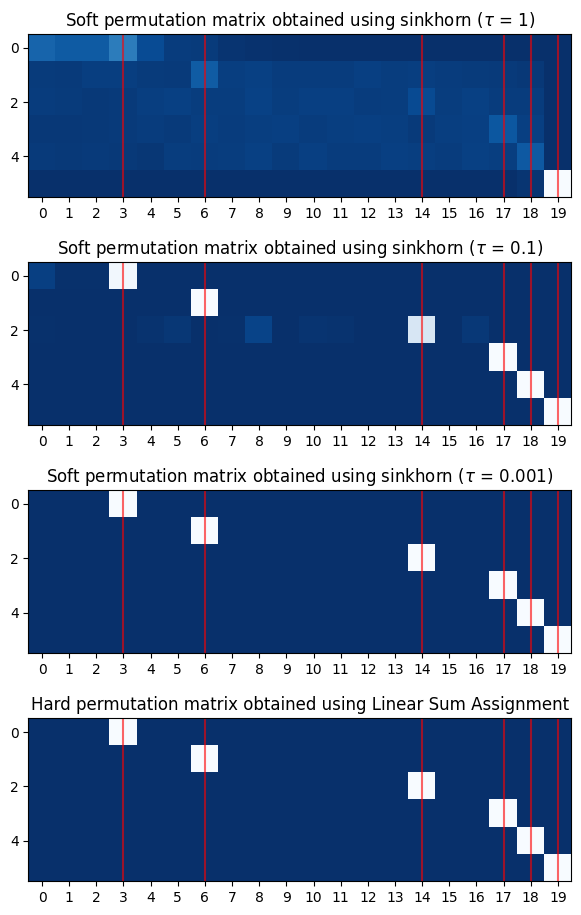

In [387]:
from gumbel_sinkhorn_ops import gumbel_matching
import matplotlib.pyplot as plt

fig, ax = plt.subplots(4,1, figsize=(10, 11))
fig.subplots_adjust(hspace=0.4)

F_mat_curr = F_mat[idx].clone()
perm1_hightau = gumbel_sinkhorn(F_mat_curr, 1, CFG.n_sink_iter, noise=False)[cpos_locs[0]]
F_mat_curr = F_mat[idx].clone()
perm2_lowtau = gumbel_sinkhorn(F_mat_curr, 0.1, CFG.n_sink_iter, noise=False)[cpos_locs[0]]
F_mat_curr = F_mat[idx].clone()
perm4_lowtau = gumbel_sinkhorn(F_mat_curr, 0.001, CFG.n_sink_iter, noise=False)[cpos_locs[0]]
F_mat_curr = F_mat[idx].clone()
perm3_match = gumbel_matching(F_mat_curr, noise=False)[cpos_locs[0]]

ax[0].imshow(perm1_hightau[:6], cmap='Blues_r')
ax[0].set_title(fr"Soft permutation matrix obtained using sinkhorn ($\tau$ = {CFG.tau})")
ax[1].imshow(perm2_lowtau[:6], cmap='Blues_r')
ax[1].set_title(fr"Soft permutation matrix obtained using sinkhorn ($\tau$ = {0.1})")
ax[2].imshow(perm4_lowtau[:6], cmap='Blues_r')
ax[2].set_title(fr"Soft permutation matrix obtained using sinkhorn ($\tau$ = {0.001})")
ax[3].imshow(perm3_match[:6], cmap='Blues_r')
ax[3].set_title(fr"Hard permutation matrix obtained using Linear Sum Assignment")

for j in range(len(ax)):
    ax[j].set_xticks(range(20))
    for i in matching_locs:
        ax[j].axvline(i, color='r', alpha=0.6)

plt.show()

torch.Size([10, 600, 20, 20])

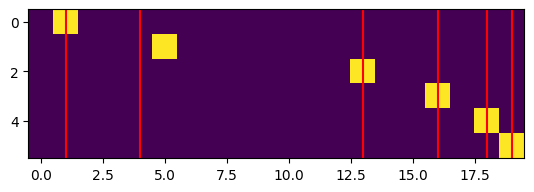

In [245]:
plt.imshow(gumbel_matching((Rm_mat.T @ qct)[0], False)[440][:6])
for i in [1, 4, 13, 16, 18, 19]:
    plt.axvline(i, color='r')

In [230]:
(A_mat @ Rm_mat)

tensor([[ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
          0.,  0.,  0.,  0.,  0.,  0.],
        [-1.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
          0.,  0.,  0.,  0.,  0.,  0.],
        [ 0., -1.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
          0.,  0.,  0.,  0.,  0.,  0.],
        [ 0.,  0., -1.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
          0.,  0.,  0.,  0.,  0.,  0.],
        [ 0.,  0.,  0., -1.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
          0.,  0.,  0.,  0.,  0.,  0.],
        [ 0.,  0.,  0.,  0., -1.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
          0.,  0.,  0.,  0.,  0.,  0.]])

In [1]:
# testing

In [3]:
import torch
import torch.nn as nn

In [9]:
m1 = nn.Linear(5, 3)
m2 = nn.Linear(5, 3)

m = nn.ModuleList([m1, m2])
opt = torch.optim.Adam(m.parameters(), lr=1e-1)

x = torch.randn(13, 5)
print(m1.weight, m2.weight, sep='\n')

y0 = m[0](x)
y1 = m[1](x)
loss = y0.mean() + y1.mean()

opt.zero_grad()
loss.backward()
opt.step()
print(m1.weight, m2.weight, sep='\n')

Parameter containing:
tensor([[ 0.4294,  0.3844,  0.3136, -0.0785, -0.2185],
        [-0.1990,  0.0558,  0.0545,  0.4184, -0.2906],
        [-0.1380, -0.1485,  0.1246,  0.2667,  0.3274]], requires_grad=True)
Parameter containing:
tensor([[ 0.1316,  0.0288, -0.1375, -0.2617, -0.0550],
        [ 0.1787, -0.2512,  0.3766, -0.3808,  0.2573],
        [ 0.3576, -0.4430,  0.1222, -0.2907,  0.2740]], requires_grad=True)
Parameter containing:
tensor([[ 0.5294,  0.4844,  0.2136,  0.0215, -0.1185],
        [-0.0990,  0.1558, -0.0455,  0.5184, -0.1906],
        [-0.0380, -0.0485,  0.0246,  0.3667,  0.4274]], requires_grad=True)
Parameter containing:
tensor([[ 0.2316,  0.1288, -0.2375, -0.1617,  0.0450],
        [ 0.2787, -0.1512,  0.2766, -0.2808,  0.3573],
        [ 0.4576, -0.3430,  0.0222, -0.1907,  0.3740]], requires_grad=True)


# Einsum testing

In [ ]:
import torch

d = dict()
for i in range(4):
    d[i] = torch.randn(17, 69, 69)
d2 = torch.randn(17,69,13)

res1 = torch.einsum("bnn,bnn,bnn,bnn,bnm->bnm",d[0],d[1],d[2],d[3],d2)
res2 = torch.bmm(torch.bmm(torch.bmm(torch.bmm(d[0], d[1]), d[2]), d[3]), d2)

In [ ]:
d[0] = d[0][0]

In [38]:
res1 = d[0] @ d[1] @ d[2]
res2 = torch.bmm(d[0][None].repeat_interleave(len(d[1]), 0), torch.bmm(d[1], d[2]))

(res1 == res2).all(), torch.nn.functional.mse_loss(res1, res2), torch.allclose(res1, res2, atol=1e-4)

(tensor(False), tensor(4.0142e-10), True)

In [82]:
(a==0).sum()

tensor(2)

In [72]:
a = torch.randn(13,17,294,34,8) # b1 x b2 x b3 x L x d

In [73]:
a.argwhere().shape

torch.Size([17672926, 5])

In [ ]:
tor

In [46]:
torch.select(a, dim=-2, index=-1).shape

torch.Size([13, 17, 294, 8])

In [11]:
# RmPC = torch.einsum("mn,bnn,bnd->bmd", Rm_mat, P, c)
# PtRmtQ = torch.einsum("bnn,nm,bmd->bnd", P.transpose(-1,-2), Rm_mat.T, q)

from main_early import *

b, m, n, d = 17, 6, 20, 128

Rm_mat = get_opas_constants(6, 20, "cpu")[2]
P = torch.randn(b,n,n)
q = torch.randn(b,m,d)
c = torch.randn(b,n,d)

RmPC = torch.einsum("mn,bnn,bnd->bmd", Rm_mat, P, c)
PtRmtQ = torch.einsum("bnn,nm,bmd->bnd", P.transpose(-1,-2), Rm_mat.T, q)

In [47]:
# RmPC sanity
for i in range(b):
    bmm_res = (Rm_mat @ torch.bmm(P, c))[i]
    manual_res = Rm_mat @ P[i] @ c[i]
    einsum_res = RmPC[i]

    assert torch.allclose(bmm_res, manual_res)
    # assert torch.allclose(einsum_res, manual_res)

In [37]:
a1 = (Rm_mat.T @ q)
a2 = torch.bmm(Rm_mat.T[None].repeat_interleave(len(q), 0), q)
assert torch.allclose(a1, a2)

In [39]:
# PtRmtQ sanity
for i in range(b):
    bmm_res = torch.bmm(P.transpose(-1,-2), Rm_mat.T @ q)[i]
    manual_res = P[i].T @ Rm_mat.T @ q[i]

    assert torch.allclose(bmm_res, manual_res)

In [41]:
# qct sanity
qct = torch.einsum("bmd,bnd->bmn", q, c)
for i in range(b):
    einsum_res = qct[i]
    manual_res = q[i] @ c[i].T
    bmm_res = torch.bmm(q, c.transpose(-1,-2))[i]

    assert torch.allclose(einsum_res, manual_res)
    assert torch.allclose(bmm_res, manual_res)

In [44]:
# qCt sanity
N = 173
C = torch.randn(N, n, d)
qCt = torch.einsum("bmd,Nnd->bNmn", q, C)
for i in range(b):
    einsum_res = qCt[i]
    manual_res = torch.stack([q[i] @ C[j].T for j in range(N)])

    assert torch.allclose(einsum_res, manual_res)

In [ ]:
# # clean all _last models
# import os, glob
# for folder in glob.glob("models/*"):
#     if ("2802" not in folder) or ("2602" not in folder) or ("2702" not in folder):
#         for f in glob.glob(f"{folder}/*_last.pt"):
#             os.remove(f)

# precision@K, map@K

In [87]:
import torch
import numpy as np
from sklearn.metrics import average_precision_score, precision_score, recall_score

N = 273
netscores = torch.rand(197, N)  # predicted scores
true_labels = torch.randint(0, 2, size=(197, N))    # ground truth (binary)

In [95]:
def get_mrr(netscores, true_labels):
    ranking = netscores.argsort(dim=1, descending=True)
    ranked_output = torch.gather(true_labels, dim=1, index=ranking)

    mRR = (1 / (ranked_output.argmax(dim=1) + 1)).mean().item()
    return mRR

def get_map(netscores, true_labels):
    ranking = netscores.argsort(dim=1, descending=True)
    ranked_output = torch.gather(true_labels, dim=1, index=ranking)

    mAP = (torch.cumsum(ranked_output, dim=1) * ranked_output).float()
    mAP /= (torch.arange(ranked_output.shape[1]) + 1)
    mAP /= torch.sum(ranked_output, dim=1, keepdim=True)
    mAP = mAP.sum(dim=1).mean().item()
    return mAP

def get_map_sk(netscores, true_labels):
    ap = []
    for i in range(len(true_labels)):
        ap.append(average_precision_score(true_labels[i], netscores[i]))
    return np.mean(ap)

print(np.allclose(get_map(netscores, true_labels), get_map_sk(netscores, true_labels)))

True


In [94]:
netscores = torch.linspace(N,1,N).unsqueeze(0).repeat_interleave(197, 0) / N
true_labels = torch.zeros(197, N)
true_labels[:, :10] = 1

def get_map_at_k(netscores, true_labels, k):
    ranking = netscores.argsort(dim=1, descending=True)
    ranked_output = torch.gather(true_labels, dim=1, index=ranking)

    MAP = (torch.cumsum(ranked_output, dim=1) * ranked_output).float()
    MAP /= (torch.arange(ranked_output.shape[1]) + 1)
    MAP /= torch.sum(ranked_output, dim=1, keepdim=True)
    MAPk = MAP[:,:k].sum(dim=1).mean().item()
    return MAPk

print(np.allclose(get_map_at_k(netscores, true_labels, k=5), 0.5))
print(np.allclose(get_map(netscores, true_labels), 1))

True
True


# checking scoremodel weight values

In [3]:
import glob
from main import *

ls = glob.glob("models/*")
betas = dict()
for expt in tqdm(ls):
    try:
        scoremodel = torch.load(f"{expt}/scmodel.pt", map_location="cpu", weights_only=False)
        betas[expt.split("/")[-1]] = scoremodel.weight.exp().detach().numpy()
    except:
        print(f"Error loading {expt}")
        continue

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 130/130 [00:00<00:00, 5287.98it/s]

Error loading models/EA16021749
Error loading models/EA03031327
Error loading models/EA03030830
Error loading models/README.md
Error loading models/ES17021038
Error loading models/EA17021038
Error loading models/EC16021749
Error loading models/EL16021749
Error loading models/ES16021749


In [17]:
arr = np.array(list(betas.values())).squeeze()

In [21]:
import matplotlib.pyplot as plt

# plt.hist(arr[:,0], bins=50, alpha=0.5, label="normscore")
# plt.hist(arr[:,1], bins=50, alpha=0.5, label="lamscore")
# plt.legend()

In [23]:
normwt = arr[:,0]
lamwt = arr[:,1]

def get_stats(arr):
    minmax = arr.min(), arr.max()
    mean = arr.mean()
    return *minmax, mean

get_stats(normwt), get_stats(lamwt)

((0.28149953, 12.3373785, 1.9208027), (0.049433224, 4.6649814, 0.76228726))

In [39]:
betas["A07021045"]

array([[0.7814611 ],
       [0.06209819]], dtype=float32)

In [40]:
betas["A25021308"]

array([[0.64082825],
       [0.08028287]], dtype=float32)

In [37]:
for k in betas.keys():
    if betas[k][1] < 0.1:
        print(k)

A20031054
A20031055
A09020550
S03031148
A26020317
A03030832
A07021045
A25021308
A01032204
A20030308
A20031038
A20030320
C11021654
A03031511
